# 🔥 TensorFlow Masterclass — From Zero to Hero
### *A Complete, Practical Deep Learning Course for All Levels*

---

**Who is this notebook for?**  
Whether you are a teenager picking up deep learning for the first time, a university student, or a working professional — this notebook is designed for **you**. The only requirement is basic Python knowledge (variables, loops, functions).

**What will you learn?**  
By the end of this notebook you will be able to:
- Understand what TensorFlow is and how it works under the hood
- Build and train neural networks from scratch
- Work with real-world image, text, and tabular datasets
- Understand loss functions, optimizers, and regularisation
- Build Convolutional Neural Networks (CNNs) for images
- Build Recurrent Neural Networks (RNNs) and LSTMs for sequences
- Save, load, and deploy trained models
- Apply best practices used in industry

**Real Datasets Used in This Notebook:**

| Dataset | Type | Used For |
|---|---|---|
| MNIST | Images — handwritten digits | Classification: your first neural net |
| CIFAR-10 | Colour images — 10 categories | CNNs deep dive |
| Boston Housing | Tabular / numerical | Regression |
| IMDb Movie Reviews | Text | Sentiment analysis with LSTM |

---
> 💡 **How to use this notebook:** Read every markdown cell carefully BEFORE running the code cell below it. Every single line of code has a comment explaining what it does. Never skip a cell — they all build on each other.


---
## SECTION 1 — What Is TensorFlow and Why Does It Matter?

### 1.1 The Big Picture

Imagine you want to teach a computer to recognise a cat in a photo.  
You cannot write rules like *"if the image has pointy ears and whiskers, it's a cat"* — that would require millions of rules and still fail.

Instead, you show the computer **thousands of labelled photos** and let it **learn the patterns itself**. This is **Machine Learning**, and the technique used for complex data like images, text, and audio is called **Deep Learning**.

**TensorFlow** is a free, open-source library created by Google in 2015. It gives us all the tools to build and train deep learning models efficiently — on CPUs, GPUs, or even mobile phones.

### 1.2 What Is a Tensor?

A **tensor** is a container for numbers — a generalisation of arrays:

| Name | Dimensions | Example |
|---|---|---|
| Scalar | 0-D | `42` |
| Vector | 1-D | `[1, 2, 3]` |
| Matrix | 2-D | `[[1,2],[3,4]]` |
| 3-D Tensor | 3 axes | An RGB image: (height, width, channels) |
| 4-D Tensor | 4 axes | A batch of images: (batch, height, width, channels) |

Everything in TensorFlow — your data, model weights, predictions — lives inside tensors.

### 1.3 The TensorFlow Ecosystem

```
TensorFlow (core library)
├── Keras          ← High-level API to build models easily (built into TF)
├── TensorBoard    ← Visualisation tool to monitor training
├── TensorFlow Lite ← For mobile and edge devices
└── TensorFlow.js  ← Run models in the browser
```


In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 — Import TensorFlow and Key Libraries
# ─────────────────────────────────────────────────────────────────

# Import TensorFlow with the alias 'tf'
# This is the universal convention — everyone writes 'tf'
import tensorflow as tf

# NumPy: TensorFlow works closely with NumPy arrays
import numpy as np

# Matplotlib: we will use this to plot images and training curves
import matplotlib.pyplot as plt

# Print the TensorFlow version so we know what we are working with
print("TensorFlow version:", tf.__version__)

# Check whether a GPU is available (speeds things up significantly)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus if gpus else "None — using CPU (perfectly fine!)")


TensorFlow version: 2.21.0
GPUs available: None — using CPU (perfectly fine!)


---
## SECTION 2 — Tensors: The Building Blocks of TensorFlow

Before building any model, we need to be completely comfortable with tensors.  
Think of this section as learning your ABCs before writing sentences.


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 — Creating Tensors
# ─────────────────────────────────────────────────────────────────

# ── Scalar (0-D tensor) ──────────────────────────────────────────
scalar = tf.constant(42)           # tf.constant() creates an immutable tensor
print("Scalar:", scalar)
print("Value:", scalar.numpy())    # .numpy() extracts the raw Python number
print("Shape:", scalar.shape)      # shape is () meaning zero dimensions
print("Data type:", scalar.dtype)  # dtype is int32 by default
print()

# ── Vector (1-D tensor) ──────────────────────────────────────────
vector = tf.constant([10, 20, 30, 40, 50])
print("Vector:", vector)
print("Shape:", vector.shape)      # (5,) — 5 elements, 1 dimension
print()

# ── Matrix (2-D tensor) ──────────────────────────────────────────
matrix = tf.constant([[1, 2, 3],
                       [4, 5, 6],
                       [7, 8, 9]])
print("Matrix:", matrix)
print("Shape:", matrix.shape)      # (3, 3) — 3 rows, 3 columns
print()

# ── 3-D Tensor (tiny 2x2 RGB image) ─────────────────────────────
tensor_3d = tf.constant([[[255, 0, 0],    # pixel (0,0): red
                           [0, 255, 0]],   # pixel (0,1): green
                          [[0, 0, 255],    # pixel (1,0): blue
                           [128,128,128]]]) # pixel (1,1): grey
print("3-D Tensor (tiny image):", tensor_3d)
print("Shape:", tensor_3d.shape)   # (2, 2, 3) — height, width, channels


Scalar: tf.Tensor(42, shape=(), dtype=int32)
Value: 42
Shape: ()
Data type: <dtype: 'int32'>

Vector: tf.Tensor([10 20 30 40 50], shape=(5,), dtype=int32)
Shape: (5,)

Matrix: tf.Tensor(
[[1 2 3]
 [4 5 6]
 [7 8 9]], shape=(3, 3), dtype=int32)
Shape: (3, 3)

3-D Tensor (tiny image): tf.Tensor(
[[[255   0   0]
  [  0 255   0]]

 [[  0   0 255]
  [128 128 128]]], shape=(2, 2, 3), dtype=int32)
Shape: (2, 2, 3)


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 — Special Tensor Creators
# ─────────────────────────────────────────────────────────────────

# A tensor of all zeros — useful for initialising weights
zeros = tf.zeros(shape=(3, 4))
print("Zeros:\n", zeros.numpy())

# A tensor of all ones
ones = tf.ones(shape=(2, 5))
print("\nOnes:\n", ones.numpy())

# Random tensor from a normal (bell-curve) distribution
# mean=0, stddev=1 are standard settings for weight initialisation
random_normal = tf.random.normal(shape=(3, 3), mean=0.0, stddev=1.0)
print("\nRandom Normal:\n", random_normal.numpy())

# Random tensor with values uniformly between minval and maxval
random_uniform = tf.random.uniform(shape=(2, 3), minval=0, maxval=10)
print("\nRandom Uniform:\n", random_uniform.numpy())

# Specify data types explicitly
float_tensor = tf.constant([1.5, 2.7, 3.14], dtype=tf.float32)
print("\nFloat tensor:", float_tensor.numpy())

int_tensor = tf.constant([1, 2, 3], dtype=tf.int64)
print("Int tensor:  ", int_tensor.numpy())


Zeros:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Ones:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]

Random Normal:
 [[ 1.0377576  -0.17928739 -0.9320212 ]
 [-0.22424747  0.29817063  0.24882802]
 [-0.6803287  -0.40663707 -0.75668544]]

Random Uniform:
 [[7.360921  0.853672  9.599166 ]
 [0.3945279 7.393097  7.9942904]]

Float tensor: [1.5  2.7  3.14]
Int tensor:   [1 2 3]


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 — Tensor Math Operations
# ─────────────────────────────────────────────────────────────────

a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
b = tf.constant([[5.0, 6.0], [7.0, 8.0]])

# Element-wise addition — adds corresponding elements
print("a + b:\n", tf.add(a, b).numpy())

# Element-wise multiplication — NOT matrix multiplication
print("\na * b (element-wise):\n", tf.multiply(a, b).numpy())

# Matrix multiplication — used in every neural network layer
# Each output element = dot product of a row of a with a column of b
print("\na @ b (matrix multiply):\n", tf.matmul(a, b).numpy())

# Transpose — flip rows and columns
print("\nTranspose of a:\n", tf.transpose(a).numpy())

# Reduce operations
print("\nSum of all elements in a:", tf.reduce_sum(a).numpy())
print("Mean of all elements in a:", tf.reduce_mean(a).numpy())
print("Max per column:", tf.reduce_max(a, axis=0).numpy())  # axis=0 means across rows

# Square root
print("\nSquare roots of [4, 9, 16]:", tf.sqrt(tf.constant([4.0, 9.0, 16.0])).numpy())


a + b:
 [[ 6.  8.]
 [10. 12.]]

a * b (element-wise):
 [[ 5. 12.]
 [21. 32.]]

a @ b (matrix multiply):
 [[19. 22.]
 [43. 50.]]

Transpose of a:
 [[1. 3.]
 [2. 4.]]

Sum of all elements in a: 10.0
Mean of all elements in a: 2.5
Max per column: [3. 4.]

Square roots of [4, 9, 16]: [2. 3. 4.]


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 — Reshaping Tensors
# ─────────────────────────────────────────────────────────────────

# Reshaping is one of the most common operations in deep learning
original = tf.constant([[1, 2, 3, 4],
                          [5, 6, 7, 8]])       # Shape: (2, 4) — 8 total elements

# Reshape to (4, 2)
reshaped_4x2 = tf.reshape(original, (4, 2))
print("Original shape:", original.shape)
print("Reshaped to (4,2):\n", reshaped_4x2.numpy())

# Flatten to 1-D — -1 means 'figure out this dimension automatically'
flattened = tf.reshape(original, (-1,))
print("\nFlattened:", flattened.numpy())

# Reshape to 3-D
reshaped_3d = tf.reshape(original, (2, 2, 2))
print("\nReshaped to (2,2,2):\n", reshaped_3d.numpy())

# expand_dims — add a new axis (very common when adding a batch dimension)
vector = tf.constant([1.0, 2.0, 3.0])          # Shape: (3,)
expanded = tf.expand_dims(vector, axis=0)        # Shape: (1, 3)
print("\nOriginal shape:", vector.shape)
print("After expand_dims:", expanded.shape)

# squeeze — remove axes of size 1
squeezed = tf.squeeze(expanded)                  # Back to (3,)
print("After squeeze:", squeezed.shape)


Original shape: (2, 4)
Reshaped to (4,2):
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]

Flattened: [1 2 3 4 5 6 7 8]

Reshaped to (2,2,2):
 [[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]

Original shape: (3,)
After expand_dims: (1, 3)
After squeeze: (3,)


---
## SECTION 3 — Variables and Automatic Differentiation

### 3.1 tf.Variable vs tf.constant

`tf.constant` — value **cannot change** after creation.  
`tf.Variable` — value **can change** — this is what model weights are, because they update during training.

### 3.2 GradientTape: The Engine Behind Training

When we train a model, we compute **gradients** — the derivative of the loss with respect to each weight. Gradients tell us which direction to nudge each weight to reduce the loss.

`tf.GradientTape()` records all operations happening inside it, then lets us "rewind the tape" to compute derivatives automatically. Think of it like a video recorder for math.


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 — tf.Variable: Learnable Parameters
# ─────────────────────────────────────────────────────────────────

# Create a Variable — this is what a model weight looks like
w = tf.Variable(3.0)
print("Initial value:", w.numpy())

w.assign(5.0)         # Set to a new value
print("After assign:", w.numpy())

w.assign_add(2.0)     # Add 2 in place — now w = 7.0
print("After assign_add:", w.numpy())

w.assign_sub(1.0)     # Subtract 1 in place — now w = 6.0
print("After assign_sub:", w.numpy())

# Variables behave like tensors in math
x = tf.constant(4.0)
result = w * x + 2    # y = 6*4 + 2 = 26
print("\nComputed (6 * 4 + 2):", result.numpy())


Initial value: 3.0
After assign: 5.0
After assign_add: 7.0
After assign_sub: 6.0

Computed (6 * 4 + 2): 26.0


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 — GradientTape: Computing Derivatives Automatically
# ─────────────────────────────────────────────────────────────────

# Compute the gradient of y = x^2 at x = 3
# Mathematically: dy/dx = 2x, so at x=3 the answer should be 6

x = tf.Variable(3.0)

with tf.GradientTape() as tape:   # Open the recording context
    y = x ** 2                    # y = x^2 — the tape records this operation

dy_dx = tape.gradient(y, x)      # Compute dy/dx by replaying the tape backwards

print("x =", x.numpy())
print("y = x^2 =", y.numpy())
print("dy/dx =", dy_dx.numpy())   # Should print 6.0


x = 3.0
y = x^2 = 9.0
dy/dx = 6.0


Epoch   0 | Loss: 2.3460 | w=0.1352 | b=0.1990
Epoch  20 | Loss: 0.0923 | w=1.5353 | b=0.9856
Epoch  40 | Loss: 0.0167 | w=1.8776 | b=0.9947
Epoch  60 | Loss: 0.0121 | w=1.9613 | b=0.9948
Epoch  80 | Loss: 0.0119 | w=1.9817 | b=0.9948

Training complete!
  Learned w = 1.9866  (true value: 2.0)
  Learned b = 0.9948  (true value: 1.0)


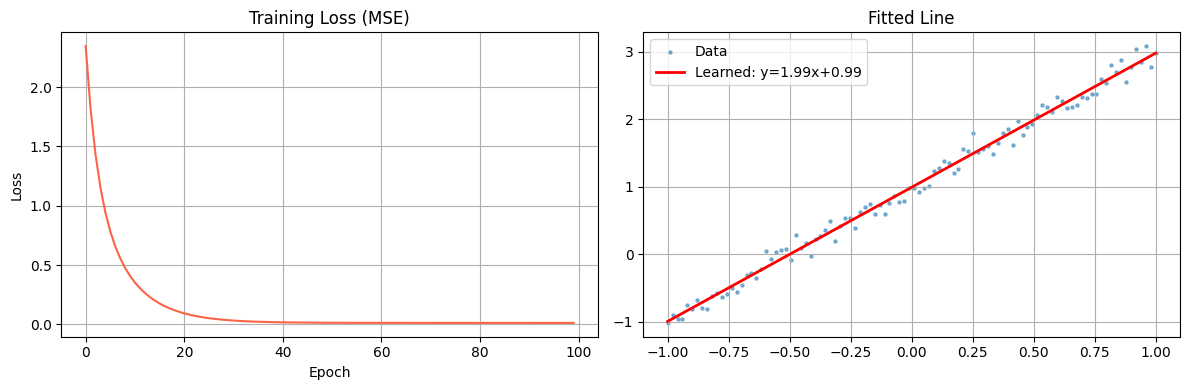

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 — Manual Gradient Descent from Scratch
# ─────────────────────────────────────────────────────────────────
#
# This is the most important cell in Section 3.
# We will manually fit a line: y = 2x + 1 using gradient descent.
# The model: y_hat = w * x + b
# We want the model to LEARN that w=2 and b=1 from data alone.

# ── Step 1: Generate training data ───────────────────────────────
x_train = np.linspace(-1, 1, 100).astype(np.float32)
y_train = 2 * x_train + 1 + np.random.normal(0, 0.1, 100).astype(np.float32)

# ── Step 2: Initialise learnable parameters ───────────────────────
w = tf.Variable(0.0)   # Start at zero — model knows nothing
b = tf.Variable(0.0)

# ── Step 3: Define the loss function ─────────────────────────────
# Mean Squared Error: average of (predicted - actual)^2
def compute_loss(y_true, y_pred):
    return tf.reduce_mean((y_true - y_pred) ** 2)

# ── Step 4: Training loop ─────────────────────────────────────────
learning_rate = 0.1   # How big a step to take each iteration
epochs = 100          # How many times we loop through the data

loss_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = w * x_train + b          # Forward pass: make predictions
        loss = compute_loss(y_train, y_pred)  # Compute error

    # Compute gradients of loss with respect to w and b
    gradients = tape.gradient(loss, [w, b])

    # Update: step in the OPPOSITE direction of the gradient (going downhill)
    w.assign_sub(learning_rate * gradients[0])
    b.assign_sub(learning_rate * gradients[1])

    loss_history.append(loss.numpy())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.numpy():.4f} | w={w.numpy():.4f} | b={b.numpy():.4f}")

print(f"\nTraining complete!")
print(f"  Learned w = {w.numpy():.4f}  (true value: 2.0)")
print(f"  Learned b = {b.numpy():.4f}  (true value: 1.0)")

# ── Step 5: Plot results ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, color='tomato')
axes[0].set_title("Training Loss (MSE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].grid(True)

axes[1].scatter(x_train, y_train, s=5, alpha=0.5, label="Data")
y_line = w.numpy() * x_train + b.numpy()
axes[1].plot(x_train, y_line, color='red', lw=2,
             label=f"Learned: y={w.numpy():.2f}x+{b.numpy():.2f}")
axes[1].set_title("Fitted Line"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


---
## SECTION 4 — Keras: The High-Level API

In Section 3 we did everything by hand — that was essential to understand the machinery.  
In practice, nobody writes raw training loops for standard models.

**Keras** (built into TensorFlow as `tf.keras`) provides clean, high-level building blocks:

| Manual approach | Keras equivalent |
|---|---|
| `w * x + b` | `tf.keras.layers.Dense` |
| `compute_loss()` | `model.compile(loss=...)` |
| `for epoch in range(...)` loop | `model.fit(...)` |
| Manual metric printing | Automatic progress bars |

### The Keras Workflow — 4 Steps

```
1. BUILD    → Define your model architecture (layers)
2. COMPILE  → Choose optimizer, loss function, and metrics
3. TRAIN    → Feed data to model.fit()
4. EVALUATE → model.evaluate() and model.predict()
```


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Learned weight: 1.9848  (true: 2.0)
Learned bias:   0.9930  (true: 1.0)
Prediction for x=0.5: 1.9855  (expected ~2.0)


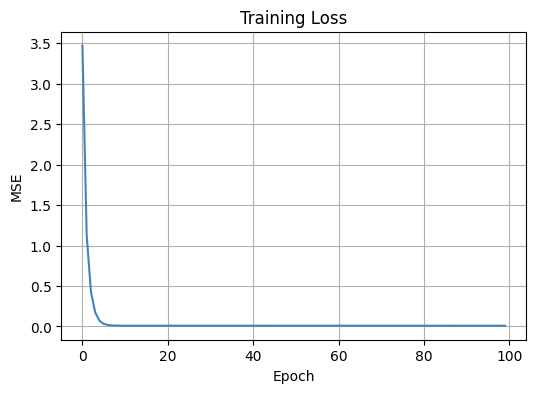

In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 9 — Your First Keras Model (Linear Regression, Clean Code)
# ─────────────────────────────────────────────────────────────────

# Same task as before: fit y = 2x + 1 — but now using Keras
x_train = np.linspace(-1, 1, 200).astype(np.float32)
y_train = 2 * x_train + 1 + np.random.normal(0, 0.1, 200).astype(np.float32)

# ── Step 1: BUILD ─────────────────────────────────────────────────
# Sequential model = layers stacked one after another
model = tf.keras.Sequential([
    # Dense layer: fully connected
    # units=1       → 1 output neuron (we want a single number)
    # input_shape=(1,) → each input is a single number
    tf.keras.layers.Dense(units=1, input_shape=(1,))
])

model.summary()   # Print the model architecture

# ── Step 2: COMPILE ──────────────────────────────────────────────
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss='mse')    # mse = Mean Squared Error

# ── Step 3: TRAIN ────────────────────────────────────────────────
history = model.fit(x_train, y_train, epochs=100, verbose=0)

# ── Step 4: EVALUATE ─────────────────────────────────────────────
learned_w = model.layers[0].get_weights()[0][0][0]   # Extract weight
learned_b = model.layers[0].get_weights()[1][0]      # Extract bias

print(f"Learned weight: {learned_w:.4f}  (true: 2.0)")
print(f"Learned bias:   {learned_b:.4f}  (true: 1.0)")

# Make a prediction
pred = model.predict(np.array([[0.5]]), verbose=0)
print(f"Prediction for x=0.5: {pred[0][0]:.4f}  (expected ~2.0)")

# Plot loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], color='steelblue')
plt.title("Training Loss"); plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.grid(True)
plt.show()


---
## SECTION 5 — Real Dataset Project 1: Boston Housing (Regression)

### What is Regression?

Regression means predicting a **continuous number** — like a price, a temperature, or a score.

### The Dataset

The **Boston Housing dataset** (inside `tf.keras.datasets`) has 506 houses in Boston suburbs, each with 13 features:

| Feature | Description |
|---|---|
| CRIM | Crime rate per capita |
| RM | Average number of rooms per dwelling |
| LSTAT | % of lower-status population |
| ... | (13 features total) |

**Target:** Median house value in $1,000s (e.g., 24 means $24,000).

### Goal: Predict house price from its 13 features.


Training samples: 404
Test samples:     102
Features per house: 13

First training house:
  CRIM    : 1.2325
  ZN      : 0.0000
  INDUS   : 8.1400
  CHAS    : 0.0000
  NOX     : 0.5380
  RM      : 6.1420
  AGE     : 91.7000
  DIS     : 3.9769
  RAD     : 4.0000
  TAX     : 307.0000
  PTRATIO : 21.0000
  B       : 396.9000
  LSTAT   : 18.7200
  Price: $15.2k

Price range: $5.0k — $50.0k


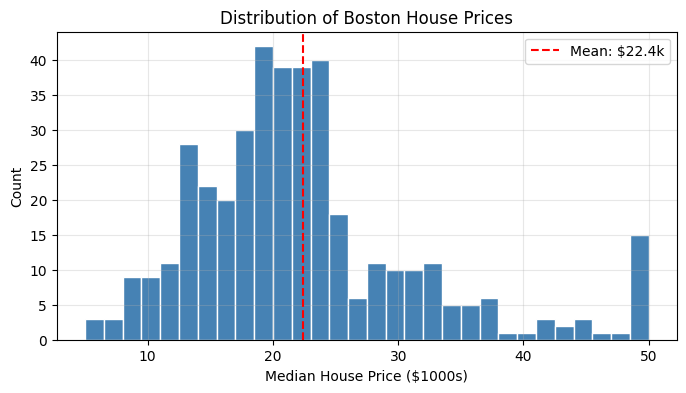

In [10]:
# ─────────────────────────────────────────────────────────────────
# CELL 10 — Load and Explore the Boston Housing Dataset
# ─────────────────────────────────────────────────────────────────

# Load — downloads automatically (small dataset, ~30 KB)
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) =     tf.keras.datasets.boston_housing.load_data()

print("Training samples:", x_train_raw.shape[0])
print("Test samples:    ", x_test_raw.shape[0])
print("Features per house:", x_train_raw.shape[1])

feature_names = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
                 'DIS','RAD','TAX','PTRATIO','B','LSTAT']

print("\nFirst training house:")
for name, value in zip(feature_names, x_train_raw[0]):
    print(f"  {name:8s}: {value:.4f}")
print(f"  Price: ${y_train_raw[0]:.1f}k")

print(f"\nPrice range: ${y_train_raw.min():.1f}k — ${y_train_raw.max():.1f}k")

# Visualise price distribution
plt.figure(figsize=(8, 4))
plt.hist(y_train_raw, bins=30, color='steelblue', edgecolor='white')
plt.axvline(y_train_raw.mean(), color='red', ls='--',
            label=f"Mean: ${y_train_raw.mean():.1f}k")
plt.xlabel("Median House Price ($1000s)"); plt.ylabel("Count")
plt.title("Distribution of Boston House Prices"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


In [11]:
# ─────────────────────────────────────────────────────────────────
# CELL 11 — Normalise Features (Critical Preprocessing)
# ─────────────────────────────────────────────────────────────────

# WHY NORMALISE?
# Features have very different ranges:
#   CRIM (crime rate): 0.006 to 89
#   TAX (tax rate): 187 to 711
# Neural networks train poorly when features are on very different scales.
#
# Z-score normalisation: normalised = (value - mean) / std
# After this, every feature has mean≈0 and std≈1
#
# IMPORTANT RULE: compute mean and std on TRAINING data only,
# then apply the SAME values to test data. Never peek at test data.

mean = x_train_raw.mean(axis=0)    # Mean of each feature across training samples
std  = x_train_raw.std(axis=0)     # Std deviation of each feature

x_train = (x_train_raw - mean) / std   # Normalise training set
x_test  = (x_test_raw  - mean) / std   # Normalise test set using TRAINING stats

print("After normalisation:")
print(f"  Training feature means (should be ~0): {x_train.mean(axis=0).round(1)}")
print(f"  Training feature stds  (should be ~1): {x_train.std(axis=0).round(1)}")
print(f"  x_train shape: {x_train.shape}")
print(f"  x_test  shape: {x_test.shape}")


After normalisation:
  Training feature means (should be ~0): [-0.  0.  0. -0. -0.  0.  0.  0.  0. -0.  0.  0.  0.]
  Training feature stds  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  x_train shape: (404, 13)
  x_test  shape: (102, 13)


In [12]:
# ─────────────────────────────────────────────────────────────────
# CELL 12 — Build the Regression Neural Network
# ─────────────────────────────────────────────────────────────────
#
# Architecture: 13 inputs → Dense(64) → Dense(32) → Dense(1)

def build_regression_model():
    model = tf.keras.Sequential([

        # Dense(64): 64 neurons, each connected to all 13 inputs
        # activation='relu': f(x) = max(0, x) — learns non-linear patterns
        tf.keras.layers.Dense(64, activation='relu', input_shape=(13,)),

        # Second hidden layer with 32 neurons
        tf.keras.layers.Dense(32, activation='relu'),

        # Output layer: 1 neuron, NO activation
        # For regression we want a raw number (not squashed to 0–1)
        tf.keras.layers.Dense(1)
    ])
    return model

model_bh = build_regression_model()
model_bh.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Training complete!
Final train MAE:      $1.54k
Final validation MAE: $2.44k
Test MAE: $2.91k  (on average, predictions are off by this amount)


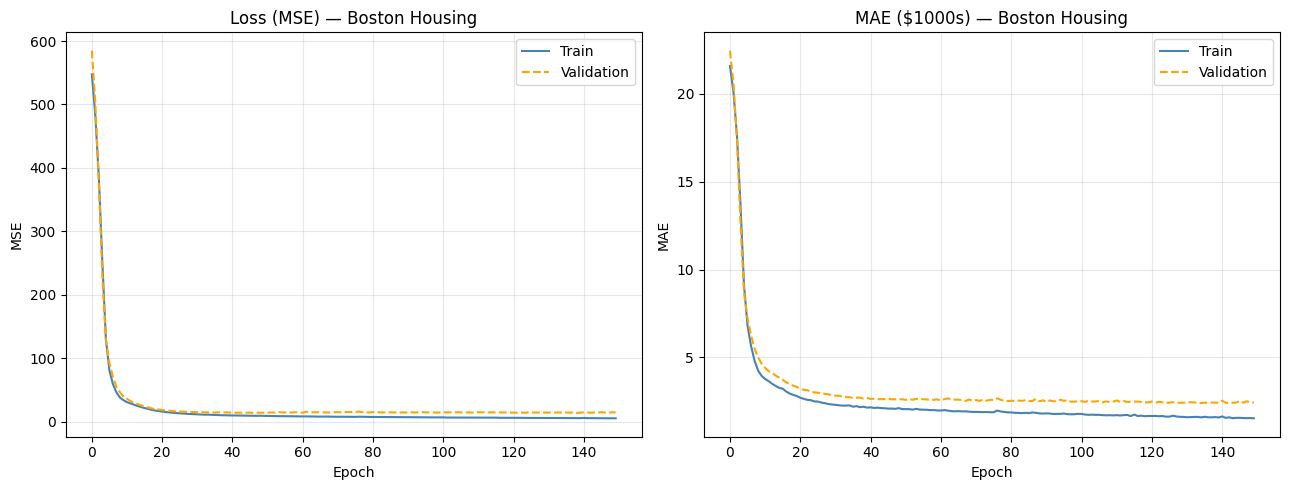

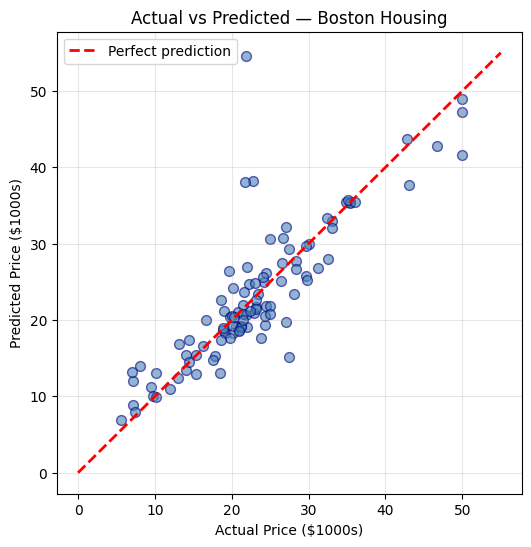

In [13]:
# ─────────────────────────────────────────────────────────────────
# CELL 13 — Compile, Train, and Evaluate the Regression Model
# ─────────────────────────────────────────────────────────────────

model_bh.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',       # Mean Squared Error for regression
    metrics=['mae']   # Mean Absolute Error — easier to interpret ($1000s)
)

history_bh = model_bh.fit(
    x_train, y_train_raw,
    epochs=150,
    batch_size=16,
    validation_split=0.2,  # Hold out 20% of training data to monitor overfitting
    verbose=0
)

print("Training complete!")
print(f"Final train MAE:      ${history_bh.history['mae'][-1]:.2f}k")
print(f"Final validation MAE: ${history_bh.history['val_mae'][-1]:.2f}k")

# Evaluate on test set
test_mse, test_mae = model_bh.evaluate(x_test, y_test_raw, verbose=0)
print(f"Test MAE: ${test_mae:.2f}k  (on average, predictions are off by this amount)")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_bh.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history_bh.history['val_loss'], label='Validation', color='orange', ls='--')
axes[0].set_title("Loss (MSE) — Boston Housing"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_bh.history['mae'],     label='Train', color='steelblue')
axes[1].plot(history_bh.history['val_mae'], label='Validation', color='orange', ls='--')
axes[1].set_title("MAE ($1000s) — Boston Housing"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Predicted vs Actual scatter plot
preds = model_bh.predict(x_test, verbose=0).flatten()
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw, preds, alpha=0.6, color='steelblue', edgecolors='navy', s=50)
plt.plot([0, 55], [0, 55], color='red', ls='--', lw=2, label='Perfect prediction')
plt.xlabel("Actual Price ($1000s)"); plt.ylabel("Predicted Price ($1000s)")
plt.title("Actual vs Predicted — Boston Housing"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


---
## SECTION 6 — Real Dataset Project 2: MNIST Handwritten Digits (Classification)

### What is Classification?

Classification means predicting which **category** something belongs to — e.g., which digit (0–9) is in this image.

### The MNIST Dataset

The "Hello, World" of deep learning:
- **70,000 greyscale images** of handwritten digits (0 through 9)
- Each image is **28 × 28 pixels**
- Split: 60,000 training + 10,000 test

### Key New Concepts

| Concept | What it does |
|---|---|
| Softmax activation | Converts raw scores into probabilities that sum to 1 |
| Sparse categorical cross-entropy | Loss function for multi-class problems |
| Dropout | Randomly deactivates neurons during training to prevent overfitting |
| Early stopping | Automatically stops training when validation accuracy stalls |


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images:     (10000, 28, 28)
Pixel range: 0 to 255
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


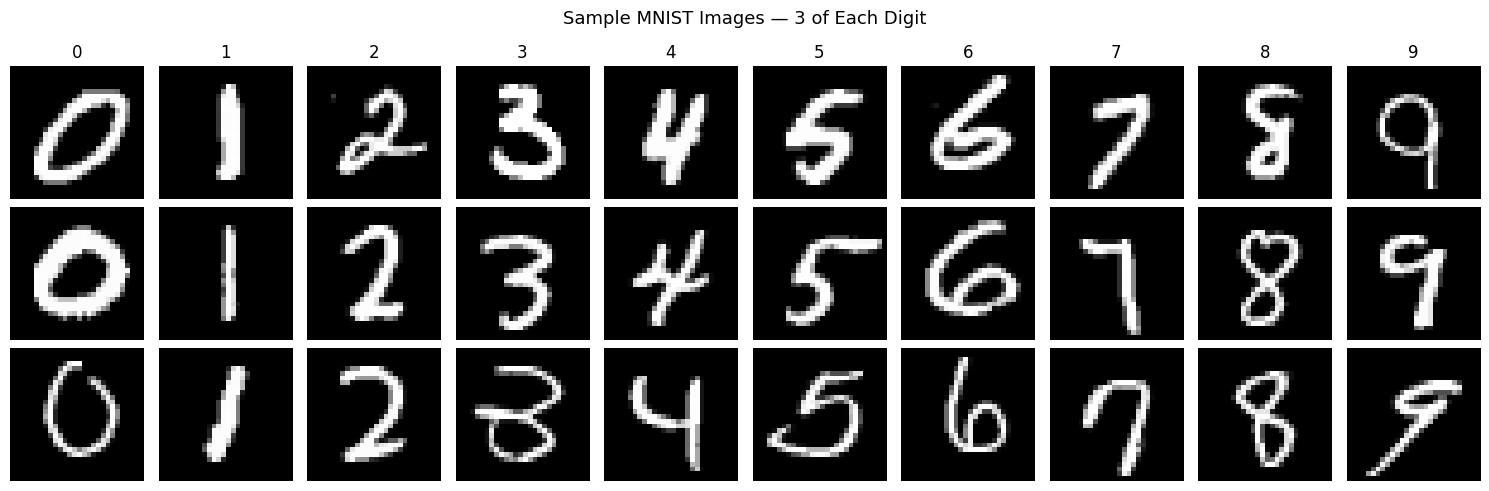

In [14]:
# ─────────────────────────────────────────────────────────────────
# CELL 14 — Load and Explore MNIST
# ─────────────────────────────────────────────────────────────────

(x_train_mn, y_train_mn), (x_test_mn, y_test_mn) = tf.keras.datasets.mnist.load_data()

print(f"Training images: {x_train_mn.shape}")  # (60000, 28, 28)
print(f"Training labels: {y_train_mn.shape}")  # (60000,)
print(f"Test images:     {x_test_mn.shape}")   # (10000, 28, 28)
print(f"Pixel range: {x_train_mn.min()} to {x_train_mn.max()}")
print(f"Classes: {sorted(set(y_train_mn.tolist()))}")

# Visualise samples — one column per digit
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle("Sample MNIST Images — 3 of Each Digit", fontsize=13)

for digit in range(10):
    indices = np.where(y_train_mn == digit)[0]
    picks = np.random.choice(indices, 3, replace=False)
    for row, idx in enumerate(picks):
        axes[row, digit].imshow(x_train_mn[idx], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=12)

plt.tight_layout(); plt.show()


In [15]:
# ─────────────────────────────────────────────────────────────────
# CELL 15 — Preprocess MNIST
# ─────────────────────────────────────────────────────────────────

# Normalise pixel values from [0, 255] to [0.0, 1.0]
x_train_mn_n = x_train_mn / 255.0
x_test_mn_n  = x_test_mn  / 255.0

# Flatten images from (28, 28) to (784,) for Dense layers
# 784 = 28 * 28
x_train_flat = x_train_mn_n.reshape(-1, 784)
x_test_flat  = x_test_mn_n.reshape(-1, 784)

print(f"Before: {x_train_mn_n.shape}  →  After flattening: {x_train_flat.shape}")


Before: (60000, 28, 28)  →  After flattening: (60000, 784)


In [16]:
# ─────────────────────────────────────────────────────────────────
# CELL 16 — Build, Compile, and Train the MNIST Classifier
# ─────────────────────────────────────────────────────────────────

# Architecture: 784 → Dense(256) → Dropout → Dense(128) → Dense(10)

mnist_model = tf.keras.Sequential([

    # Dense(256): 256 neurons, each connected to all 784 pixel inputs
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),

    # Dropout(0.3): randomly set 30% of neuron outputs to 0 during training
    # Forces the network not to rely on any single neuron → prevents overfitting
    # During prediction, dropout is automatically turned OFF
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    # Output: 10 neurons (one per digit)
    # Softmax turns raw scores into probabilities that sum to 1
    # e.g. [0.01, 0.02, 0.01, 0.9, ...] → 90% confident this is a "3"
    tf.keras.layers.Dense(10, activation='softmax')
])

mnist_model.summary()

mnist_model.compile(
    optimizer='adam',
    # sparse_categorical_crossentropy: use when labels are integers (0–9)
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping: stop if val_accuracy doesn't improve for 5 epochs
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

history_mn = mnist_model.fit(
    x_train_flat, y_train_mn,
    epochs=30, batch_size=128,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8818 - loss: 0.3873 - val_accuracy: 0.9621 - val_loss: 0.1309
Epoch 2/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9502 - loss: 0.1669 - val_accuracy: 0.9690 - val_loss: 0.1030
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9621 - loss: 0.1241 - val_accuracy: 0.9734 - val_loss: 0.0880
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9702 - loss: 0.0996 - val_accuracy: 0.9737 - val_loss: 0.0871
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9729 - loss: 0.0872 - val_accuracy: 0.9769 - val_loss: 0.0772
Epoch 6/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9760 - loss: 0.0745 - val_accuracy: 0.9793 - val_loss: 0.0721
Epoch 7/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9789 - loss: 0.0663 - val_accuracy: 0.9796 - val_loss: 0.0712
Epoch 8/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9807 - loss: 0.0593 - val_a

Test Accuracy: 98.34%
Test Loss:     0.0563


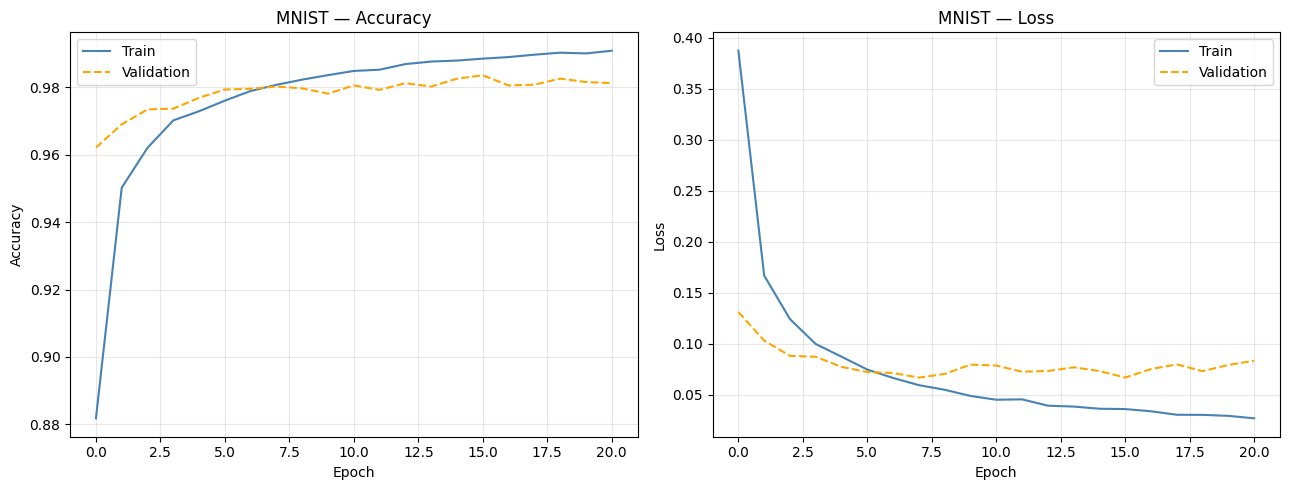

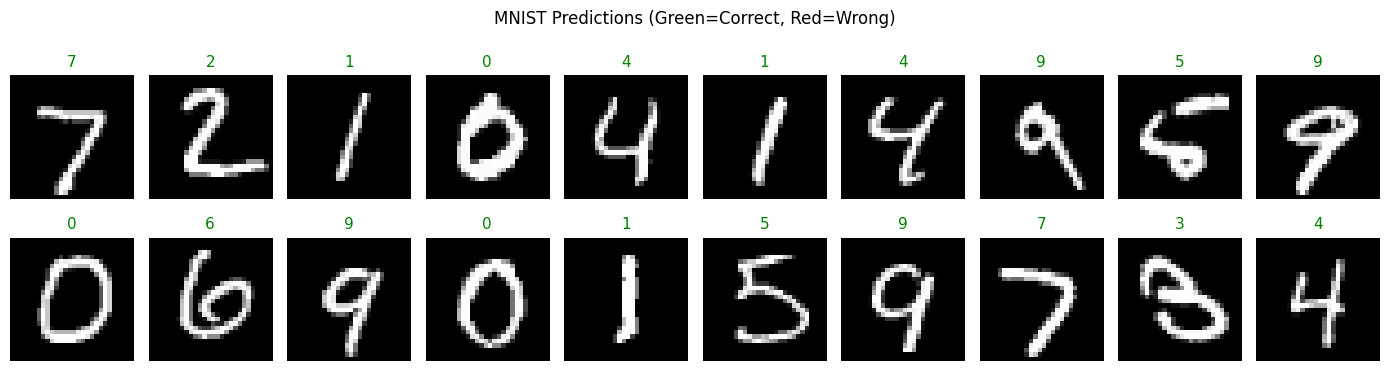

In [17]:
# ─────────────────────────────────────────────────────────────────
# CELL 17 — Evaluate the MNIST Classifier
# ─────────────────────────────────────────────────────────────────

test_loss_mn, test_acc_mn = mnist_model.evaluate(x_test_flat, y_test_mn, verbose=0)
print(f"Test Accuracy: {test_acc_mn * 100:.2f}%")
print(f"Test Loss:     {test_loss_mn:.4f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_mn.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history_mn.history['val_accuracy'], label='Validation', color='orange', ls='--')
axes[0].set_title("MNIST — Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_mn.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history_mn.history['val_loss'], label='Validation', color='orange', ls='--')
axes[1].set_title("MNIST — Loss"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Predictions on test images
y_pred_mn = np.argmax(mnist_model.predict(x_test_flat[:20], verbose=0), axis=1)

fig, axes = plt.subplots(2, 10, figsize=(14, 4))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(x_test_mn[i], cmap='gray')
    correct = y_pred_mn[i] == y_test_mn[i]
    ax.set_title(str(y_pred_mn[i]), fontsize=11,
                 color='green' if correct else 'red')
    ax.axis('off')
plt.suptitle("MNIST Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout(); plt.show()


---
## SECTION 7 — Convolutional Neural Networks (CNNs) with CIFAR-10

### Why CNNs?

When we flattened images for Dense layers, we destroyed spatial structure.  
A CNN instead looks at small **local patches** of the image (e.g., 3×3 pixels), sharing the same filter weights across the entire image. This means:
- Far fewer parameters (efficient)
- Spatial awareness (understands where things are)
- Learnable feature detectors (edges, textures, shapes, objects)

### The CIFAR-10 Dataset

10 classes of 32×32 colour photographs:  
Airplane, Car, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck  
60,000 training + 10,000 test images

### CNN Architecture We Will Build

```
Input (32×32×3)
  → Conv2D(32) + ReLU     ← learn edge and colour detectors
  → Conv2D(32) + ReLU
  → MaxPooling2D(2×2)      ← downsample: 32×32 → 16×16
  → Dropout(0.25)
  → Conv2D(64) + ReLU     ← learn shape detectors
  → Conv2D(64) + ReLU
  → MaxPooling2D(2×2)      ← downsample: 16×16 → 8×8
  → Dropout(0.25)
  → Flatten → Dense(512) → Dropout(0.5) → Dense(10, softmax)
```


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4779s 28us/step
Training images: (50000, 32, 32, 3)
Test images:     (10000, 32, 32, 3)
Pixel range: 0 to 255


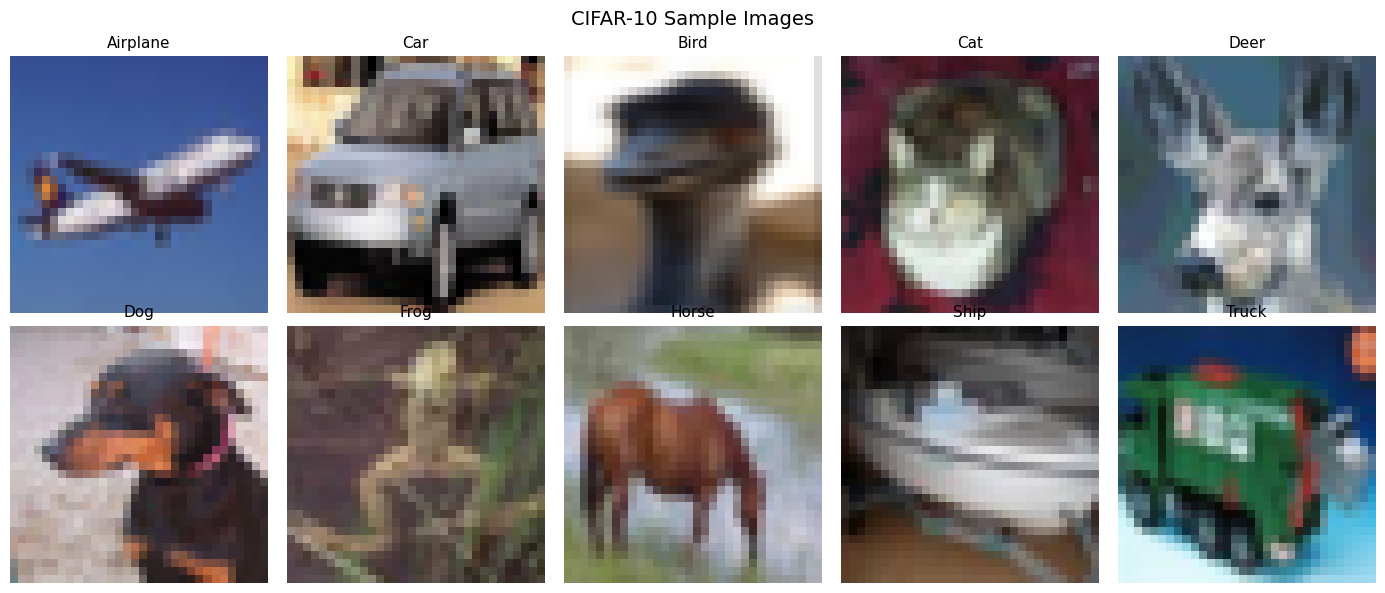

In [18]:
# ─────────────────────────────────────────────────────────────────
# CELL 18 — Load and Explore CIFAR-10
# ─────────────────────────────────────────────────────────────────

(x_train_cf, y_train_cf), (x_test_cf, y_test_cf) = tf.keras.datasets.cifar10.load_data()

class_names = ['Airplane','Car','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

print("Training images:", x_train_cf.shape)  # (50000, 32, 32, 3)
print("Test images:    ", x_test_cf.shape)   # (10000, 32, 32, 3)
print("Pixel range:", x_train_cf.min(), "to", x_train_cf.max())

y_train_cf = y_train_cf.squeeze()   # (50000, 1) → (50000,)
y_test_cf  = y_test_cf.squeeze()

# Normalise to [0.0, 1.0]
x_train_cf = x_train_cf.astype('float32') / 255.0
x_test_cf  = x_test_cf.astype('float32')  / 255.0

# Show sample images — one per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("CIFAR-10 Sample Images", fontsize=14)
for i in range(10):
    idx = np.random.choice(np.where(y_train_cf == i)[0])
    axes[i // 5, i % 5].imshow(x_train_cf[idx])
    axes[i // 5, i % 5].set_title(class_names[i], fontsize=11)
    axes[i // 5, i % 5].axis('off')
plt.tight_layout(); plt.show()


In [19]:
# ─────────────────────────────────────────────────────────────────
# CELL 19 — Build the CNN
# ─────────────────────────────────────────────────────────────────

def build_cnn():
    model = tf.keras.Sequential([

        # ── Block 1 ──────────────────────────────────────────────
        # Conv2D(32, 3x3): 32 filters of size 3×3
        # padding='same': add zeros around border so output has same spatial size
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu',
                               input_shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),

        # MaxPooling2D: slide a 2×2 window, keep only the max value
        # Reduces spatial dimensions: 32×32 → 16×16
        # Makes the network less sensitive to small position shifts
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Dropout(0.25),

        # ── Block 2 ──────────────────────────────────────────────
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),   # 16×16 → 8×8
        tf.keras.layers.Dropout(0.25),

        # ── Classification head ───────────────────────────────────
        # After 2 MaxPool layers: 32→16→8, with 64 filters → 8×8×64 = 4096 values
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

cnn_model = build_cnn()
cnn_model.summary()


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,362 (8.27 MB)

 Trainable params: 2,168,362 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

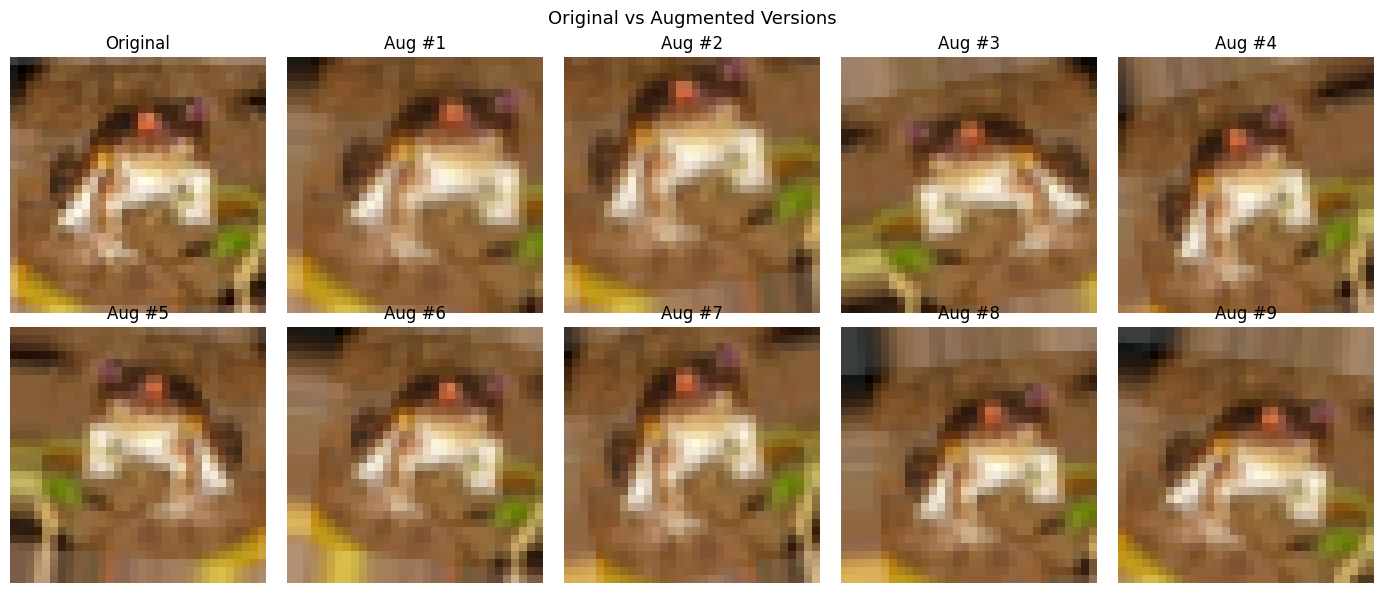

In [20]:
# ─────────────────────────────────────────────────────────────────
# CELL 20 — Data Augmentation for CIFAR-10
# ─────────────────────────────────────────────────────────────────
#
# Data augmentation = randomly transform training images on the fly
# The model sees more variety → learns more robust features
# A car is still a car even when flipped horizontally or slightly zoomed

datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,    # Randomly flip left-right
    width_shift_range=0.1,   # Shift left/right by up to 10%
    height_shift_range=0.1,  # Shift up/down by up to 10%
    rotation_range=15,       # Rotate by up to 15 degrees
    zoom_range=0.1           # Zoom in/out by up to 10%
)
datagen.fit(x_train_cf)

# Show augmented examples from one image
sample = x_train_cf[0:1]    # One image, shape (1, 32, 32, 3)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Original vs Augmented Versions", fontsize=13)
axes[0, 0].imshow(x_train_cf[0]); axes[0, 0].set_title("Original"); axes[0, 0].axis('off')
augmented = datagen.flow(sample, batch_size=1)
for i in range(1, 10):
    ax = axes[i // 5, i % 5]
    ax.imshow(next(augmented)[0])
    ax.set_title(f"Aug #{i}"); ax.axis('off')
plt.tight_layout(); plt.show()


In [21]:
# ─────────────────────────────────────────────────────────────────
# CELL 21 — Compile and Train the CNN
# ─────────────────────────────────────────────────────────────────

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ReduceLROnPlateau: if val_accuracy stops improving, halve the learning rate
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=3,
    min_lr=1e-6, verbose=1
)
early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8, restore_best_weights=True
)

print("Training CNN on CIFAR-10...")
print("NOTE: This may take 5–15 minutes on CPU. On GPU it is much faster.")

history_cnn = cnn_model.fit(
    datagen.flow(x_train_cf, y_train_cf, batch_size=64),
    steps_per_epoch=len(x_train_cf) // 64,
    epochs=30,
    validation_data=(x_test_cf, y_test_cf),
    callbacks=[reduce_lr, early_stop_cnn],
    verbose=1
)


Training CNN on CIFAR-10...
NOTE: This may take 5–15 minutes on CPU. On GPU it is much faster.
Epoch 1/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 134s 168ms/step - accuracy: 0.4008 - loss: 1.6290 - val_accuracy: 0.5626 - val_loss: 1.2214 - learning_rate: 0.0010
Epoch 2/30
  1/781 ━━━━━━━━━━━━━━━━━━━━ 1:32 118ms/step - accuracy: 0.5156 - loss: 1.5747

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5156 - loss: 1.5747 - val_accuracy: 0.5592 - val_loss: 1.2296 - learning_rate: 0.0010
Epoch 3/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 171s 218ms/step - accuracy: 0.5361 - loss: 1.2931 - val_accuracy: 0.6313 - val_loss: 1.0247 - learning_rate: 0.0010
Epoch 4/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6562 - loss: 1.1020 - val_accuracy: 0.6306 - val_loss: 1.0298 - learning_rate: 0.0010
Epoch 5/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 183s 234ms/step - accuracy: 0.5834 - loss: 1.1686 - val_accuracy: 0.6466 - val_loss: 0.9834 - learning_rate: 0.0010
Epoch 6/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7188 - loss: 1.0128 - val_accuracy: 0.6584 - val_loss: 0.9563 - learning_rate: 0.0010
Epoch 7/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 232s 298ms/step - accuracy: 0.6159 - loss: 1.0855 - val_accuracy: 0.6462 - val_loss: 0.9883 - learning_rate: 0.0010
Epoch 8/30
781/781 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7031 - loss: 0.9303 

CNN Test Accuracy: 75.68%
CNN Test Loss:     0.7074


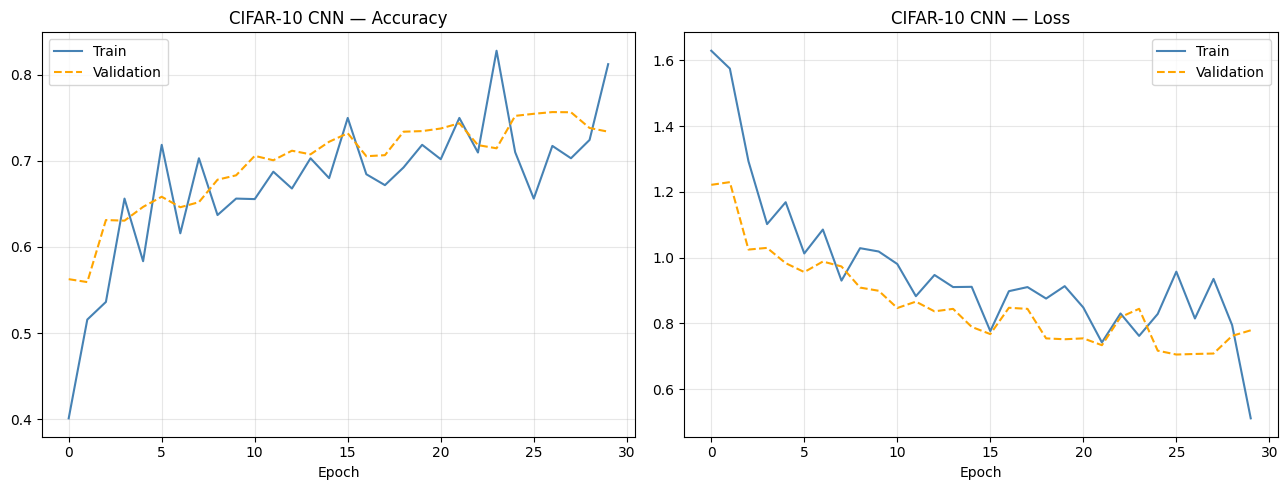

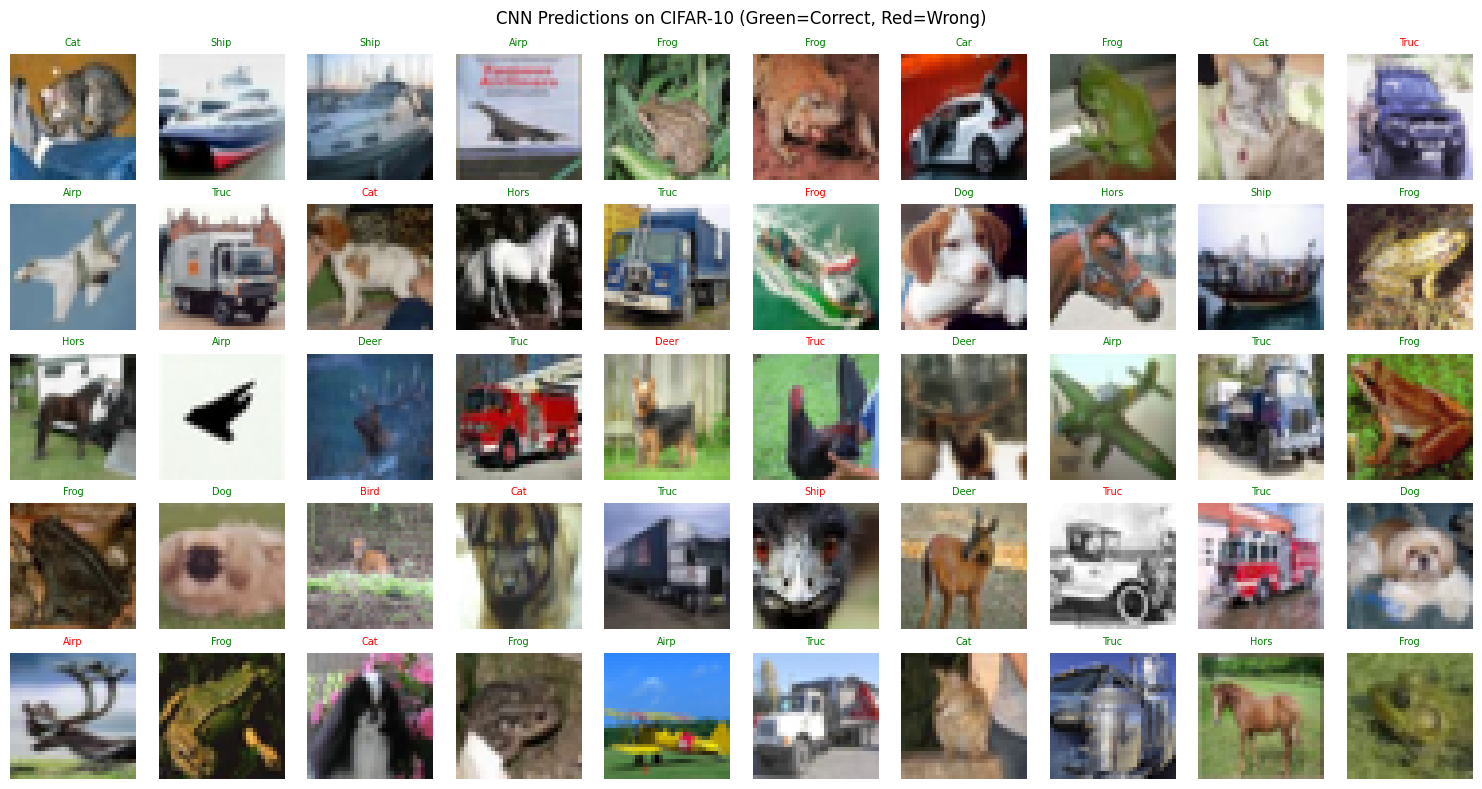

In [22]:
# ─────────────────────────────────────────────────────────────────
# CELL 22 — Evaluate the CNN
# ─────────────────────────────────────────────────────────────────

test_loss_cnn, test_acc_cnn = cnn_model.evaluate(x_test_cf, y_test_cf, verbose=0)
print(f"CNN Test Accuracy: {test_acc_cnn * 100:.2f}%")
print(f"CNN Test Loss:     {test_loss_cnn:.4f}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history_cnn.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation', color='orange', ls='--')
axes[0].set_title("CIFAR-10 CNN — Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history_cnn.history['val_loss'], label='Validation', color='orange', ls='--')
axes[1].set_title("CIFAR-10 CNN — Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Show predictions
y_pred_cf = np.argmax(cnn_model.predict(x_test_cf[:50], verbose=0), axis=1)
fig, axes = plt.subplots(5, 10, figsize=(15, 8))
fig.suptitle("CNN Predictions on CIFAR-10 (Green=Correct, Red=Wrong)", fontsize=12)
for i in range(50):
    ax = axes[i // 10, i % 10]
    ax.imshow(x_test_cf[i])
    correct = y_pred_cf[i] == y_test_cf[i]
    ax.set_title(class_names[y_pred_cf[i]][:4], fontsize=7,
                 color='green' if correct else 'red')
    ax.axis('off')
plt.tight_layout(); plt.show()


---
## SECTION 8 — Recurrent Neural Networks and LSTMs with IMDb Reviews

### Why RNNs?

Dense and CNN layers process inputs of a **fixed size** in **no particular order**.  
But language is **sequential** — meaning depends on what came before.

> "The movie was not **bad** at all." ← positive  
> "The movie was **bad**, not good at all." ← negative

A **Recurrent Neural Network (RNN)** processes one word at a time, carrying a hidden "memory" state forward.

### LSTM — Long Short-Term Memory

Standard RNNs forget information from many steps ago (vanishing gradients).  
LSTMs solve this with **gates** — forget gate, input gate, output gate — that control what to remember.

### The IMDb Dataset

50,000 movie reviews labelled Positive (1) or Negative (0).  
Task: read a review and predict sentiment.


In [23]:
# ─────────────────────────────────────────────────────────────────
# CELL 23 — Load and Explore IMDb
# ─────────────────────────────────────────────────────────────────

NUM_WORDS = 10000   # Only keep the 10,000 most common words

(x_train_imdb, y_train_imdb), (x_test_imdb, y_test_imdb) =     tf.keras.datasets.imdb.load_data(num_words=NUM_WORDS)

print("Training reviews:", len(x_train_imdb))   # 25,000
print("Test reviews:    ", len(x_test_imdb))    # 25,000

# Reviews are already encoded as integer word indices
print("First review (first 20 tokens):", x_train_imdb[0][:20])
print("Label:", y_train_imdb[0], "(1=Positive, 0=Negative)")

# Decode back to readable text
word_index = tf.keras.datasets.imdb.get_word_index()
rev_index  = {v + 3: k for k, v in word_index.items()}
rev_index[0] = '[PAD]'; rev_index[1] = '[START]'; rev_index[2] = '[UNK]'

def decode_review(seq):
    return ' '.join([rev_index.get(i, '?') for i in seq])

print("\nFirst review decoded:")
print(decode_review(x_train_imdb[0][:80]), "...")
print("Label:", "POSITIVE" if y_train_imdb[0] == 1 else "NEGATIVE")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training reviews: 25000
Test reviews:     25000
First review (first 20 tokens): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Label: 1 (1=Positive, 0=Negative)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step

First review decoded:
[START] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [UNK] is an amazing actor and now the same being director [UNK] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as ...
Label: POSITIVE


In [24]:
# ─────────────────────────────────────────────────────────────────
# CELL 24 — Pad Sequences and Build the LSTM Model
# ─────────────────────────────────────────────────────────────────

MAX_LEN = 200   # Use the first 200 words of each review

# All reviews must be the same length
# Shorter reviews get zeros added at the start (padding)
# Longer reviews get truncated from the end
x_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    x_train_imdb, maxlen=MAX_LEN, padding='pre', truncating='post')
x_test_pad = tf.keras.preprocessing.sequence.pad_sequences(
    x_test_imdb, maxlen=MAX_LEN, padding='pre', truncating='post')

print(f"After padding: x_train={x_train_pad.shape}, x_test={x_test_pad.shape}")

# ── Build the LSTM model ──────────────────────────────────────────
EMBEDDING_DIM = 64   # Each word becomes a 64-dimensional vector

lstm_model = tf.keras.Sequential([

    # Embedding: converts integer word IDs → dense vectors
    # Think of it as a lookup table: word 42 → [0.3, -0.1, ...] (64 numbers)
    # These vectors are LEARNED during training
    tf.keras.layers.Embedding(input_dim=NUM_WORDS,
                              output_dim=EMBEDDING_DIM,
                              input_length=MAX_LEN),

    # LSTM(64): processes 200 word vectors one at a time
    # By the end, it has a 64-number summary of the entire review
    tf.keras.layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    # Output: 1 neuron with sigmoid → probability between 0 and 1
    # > 0.5 = predicted positive, < 0.5 = predicted negative
    tf.keras.layers.Dense(1, activation='sigmoid')
])

lstm_model.summary()

lstm_model.compile(optimizer='adam',
                   loss='binary_crossentropy',  # Binary: 2 classes only
                   metrics=['accuracy'])


After padding: x_train=(25000, 200), x_test=(25000, 200)


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 74s 432ms/step - accuracy: 0.6908 - loss: 0.5824 - val_accuracy: 0.8224 - val_loss: 0.4105
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 435ms/step - accuracy: 0.8284 - loss: 0.4015 - val_accuracy: 0.8044 - val_loss: 0.4298
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 383ms/step - accuracy: 0.8535 - loss: 0.3608 - val_accuracy: 0.8404 - val_loss: 0.3874
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 53s 335ms/step - accuracy: 0.8892 - loss: 0.2954 - val_accuracy: 0.8352 - val_loss: 0.4007
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 359ms/step - accuracy: 0.8984 - loss: 0.2700 - val_accuracy: 0.8320 - val_loss: 0.4003
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 72s 292ms/step - accuracy: 0.9122 - loss: 0.2398 - val_accuracy: 0.8262 - val_loss: 0.4185

LSTM Test Accuracy: 82.58%


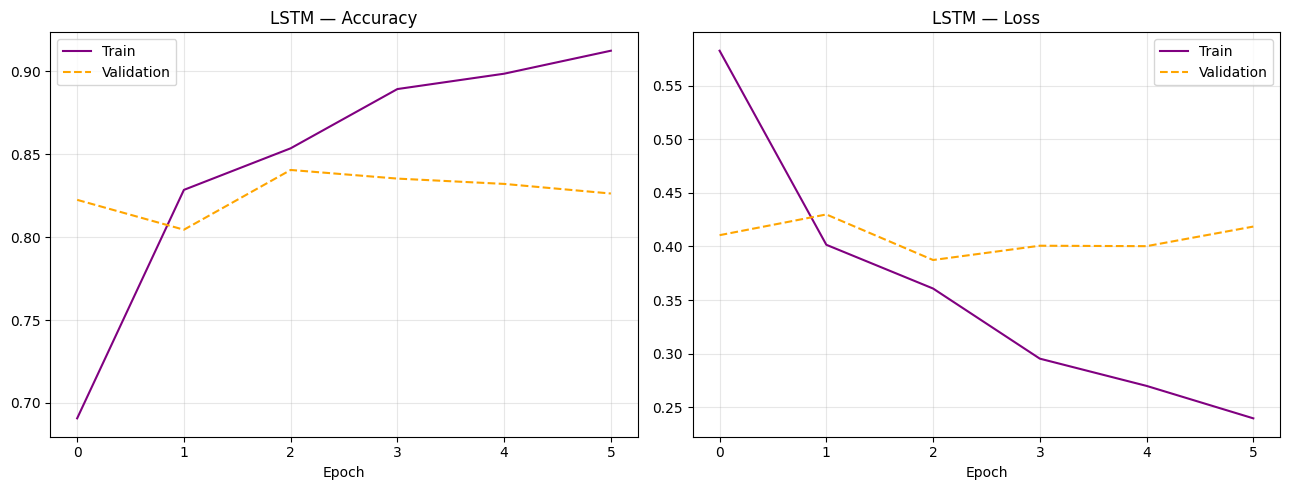

Sample Predictions:
[OK] Prob=0.161 | True=NEG | Predicted=NEG
  Review: [START] please give this one a miss br br [UNK] [UNK] and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going ...

[OK] Prob=0.987 | True=POS | Predicted=POS
  Review: [START] this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances [UNK] the sandy dennis character apartment but the film builds to a disturbing climax br br ...

[OK] Prob=0.894 | True=POS | Predicted=POS
  Review: [START] many animation buffs consider [UNK] [UNK] the great forgotten genius of one special branch of the art puppet animation which he invented almost single [UNK] and as it happened almost accidentally as a young man [UNK] was more interested in [UNK] than the cinema but hi

In [25]:
# ─────────────────────────────────────────────────────────────────
# CELL 25 — Train and Evaluate the LSTM
# ─────────────────────────────────────────────────────────────────

early_stop_lstm = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=3, restore_best_weights=True)

history_lstm = lstm_model.fit(
    x_train_pad, y_train_imdb,
    epochs=10, batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop_lstm],
    verbose=1
)

test_loss_lstm, test_acc_lstm = lstm_model.evaluate(x_test_pad, y_test_imdb, verbose=0)
print(f"\nLSTM Test Accuracy: {test_acc_lstm * 100:.2f}%")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history_lstm.history['accuracy'],     label='Train', color='purple')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation', color='orange', ls='--')
axes[0].set_title("LSTM — Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history['loss'],     label='Train', color='purple')
axes[1].plot(history_lstm.history['val_loss'], label='Validation', color='orange', ls='--')
axes[1].set_title("LSTM — Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Make predictions on some test reviews
def predict_sentiment(idx):
    padded = x_test_pad[idx].reshape(1, MAX_LEN)
    prob = lstm_model.predict(padded, verbose=0)[0][0]
    pred = 1 if prob > 0.5 else 0
    correct = pred == y_test_imdb[idx]
    marker = "OK" if correct else "WRONG"
    true_lbl = "POS" if y_test_imdb[idx] == 1 else "NEG"
    pred_lbl = "POS" if pred == 1 else "NEG"
    print(f"[{marker}] Prob={prob:.3f} | True={true_lbl} | Predicted={pred_lbl}")
    print(f"  Review: {decode_review(x_test_imdb[idx][:50])} ...")
    print()

print("Sample Predictions:")
for i in [0, 1, 2, 5, 10]:
    predict_sentiment(i)


---
## SECTION 9 — Saving and Loading Models

Training takes time. Once trained, you want to:
- **Save** to disk so you don't retrain from scratch
- **Load** to make predictions later
- **Export** to deploy in a web app or mobile phone

| Format | Extension | Notes |
|---|---|---|
| SavedModel | `.keras` | Recommended — saves architecture + weights + optimizer |
| HDF5 | `.h5` | Legacy — still widely used |
| Weights only | `.weights.h5` | Lighter — need to rebuild architecture separately |


In [26]:
# ─────────────────────────────────────────────────────────────────
# CELL 26 — Save and Load a Model
# ─────────────────────────────────────────────────────────────────

import os

# Save in the modern .keras format
mnist_model.save("mnist_classifier.keras")
print(f"Saved! File size: {os.path.getsize('mnist_classifier.keras') / 1024:.1f} KB")

# Load the model back
loaded_model = tf.keras.models.load_model("mnist_classifier.keras")
print("Model loaded successfully!")

# Verify predictions match
orig_pred   = np.argmax(mnist_model.predict(x_test_flat[:5], verbose=0), axis=1)
loaded_pred = np.argmax(loaded_model.predict(x_test_flat[:5], verbose=0), axis=1)
print(f"Original predictions: {orig_pred}")
print(f"Loaded predictions:   {loaded_pred}")
print("Match:", np.array_equal(orig_pred, loaded_pred))

# Save only weights (lighter file)
mnist_model.save_weights("mnist_weights.weights.h5")
print("\nWeights saved to: mnist_weights.weights.h5")

# Save in HDF5 legacy format
mnist_model.save("mnist_classifier.h5")
loaded_h5 = tf.keras.models.load_model("mnist_classifier.h5")
print("HDF5 model loaded OK!")


Saved! File size: 2784.8 KB
Model loaded successfully!


Original predictions: [7 2 1 0 4]
Loaded predictions:   [7 2 1 0 4]
Match: True

Weights saved to: mnist_weights.weights.h5
HDF5 model loaded OK!


---
## SECTION 10 — The Functional API (Complex Architectures)

The `Sequential` API is great for simple stacks.  
The **Functional API** lets you build models with:
- Multiple inputs (e.g., image + metadata)
- Multiple outputs (e.g., classify + detect location)
- Skip connections (ResNet-style)
- Branching (Inception-style)


In [27]:
# ─────────────────────────────────────────────────────────────────
# CELL 27 — Functional API: Multi-Input Model
# ─────────────────────────────────────────────────────────────────
#
# Model with TWO inputs:
#   1. Image pixels (784 values from MNIST)
#   2. Fake metadata (1 number: image brightness)
# ONE output: digit class (0-9)

# ── Input 1: image ────────────────────────────────────────────────
image_input = tf.keras.Input(shape=(784,), name="image_input")
x1 = tf.keras.layers.Dense(128, activation='relu')(image_input)
x1 = tf.keras.layers.Dense(64,  activation='relu')(x1)

# ── Input 2: metadata ─────────────────────────────────────────────
meta_input = tf.keras.Input(shape=(1,), name="meta_input")
x2 = tf.keras.layers.Dense(8, activation='relu')(meta_input)

# ── Merge both branches ───────────────────────────────────────────
merged = tf.keras.layers.Concatenate(name="merge")([x1, x2])

# ── Classification head ───────────────────────────────────────────
out = tf.keras.layers.Dense(32, activation='relu')(merged)
output = tf.keras.layers.Dense(10, activation='softmax', name="predictions")(out)

# ── Define the model with multiple inputs ─────────────────────────
multi_model = tf.keras.Model(inputs=[image_input, meta_input], outputs=output)
multi_model.summary()

multi_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Create fake metadata (random brightness values for each image)
meta_train = np.random.rand(len(x_train_flat), 1).astype(np.float32)
meta_test  = np.random.rand(len(x_test_flat), 1).astype(np.float32)

# Train: pass a LIST of inputs
print("Training multi-input model...")
history_multi = multi_model.fit(
    [x_train_flat, meta_train],   # Two inputs
    y_train_mn,
    epochs=5, batch_size=128,
    validation_split=0.1, verbose=1
)

_, test_acc_multi = multi_model.evaluate([x_test_flat, meta_test], y_test_mn, verbose=0)
print(f"Multi-input model test accuracy: {test_acc_multi * 100:.2f}%")


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 128)       │    100,480 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │      8,256 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 8)         │         16 │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 72)        │          0 │ dense_12[0][0],   │
│                     │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      2,336 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 10)        │        330 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 111,418 (435.23 KB)

 Trainable params: 111,418 (435.23 KB)

 Non-trainable params: 0 (0.00 B)

Training multi-input model...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8861 - loss: 0.3912 - val_accuracy: 0.9623 - val_loss: 0.1422
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9569 - loss: 0.1460 - val_accuracy: 0.9725 - val_loss: 0.0986
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9696 - loss: 0.1007 - val_accuracy: 0.9743 - val_loss: 0.0868
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9760 - loss: 0.0756 - val_accuracy: 0.9750 - val_loss: 0.0939
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9811 - loss: 0.0612 - val_accuracy: 0.9750 - val_loss: 0.0822
Multi-input model test accuracy: 97.32%


---
## SECTION 11 — Transfer Learning: Using Pretrained Models

### What Is Transfer Learning?

Training a CNN from scratch on image data requires millions of images and days of GPU time.  
**Transfer learning** reuses a model already trained on a massive dataset (ImageNet: 1.2M images) for your own task.

The early layers learn universal features:  
Layer 1 → edges and colours | Layer 2 → textures | Layer 3 → shapes | Layer 4+ → objects

These features are useful for ANY image task.

### Workflow

```
1. Load pretrained model (MobileNetV2, ResNet50, EfficientNet…) WITHOUT top layers
2. Freeze the base — don't train its weights yet
3. Add YOUR own classification head on top
4. Train only the head on your data
5. (Optional) Fine-tune: unfreeze last N layers and retrain with tiny learning rate
```


In [28]:
# ─────────────────────────────────────────────────────────────────
# CELL 28 — Transfer Learning with MobileNetV2 on CIFAR-10
# ─────────────────────────────────────────────────────────────────

# MobileNetV2 expects images of at least 32×32
# CIFAR-10 is 32×32 but was trained at 224×224 — we resize to 96×96
TARGET_SIZE = 96

def preprocess_for_mobilenet(image, label):
    image = tf.image.resize(image, [TARGET_SIZE, TARGET_SIZE])
    # preprocess_input scales pixels from [0,255] to [-1, 1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
    return image, label

# Build tf.data pipelines for efficient loading
BATCH_SIZE = 64
train_ds = (tf.data.Dataset.from_tensor_slices((x_train_cf, y_train_cf))
            .map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((x_test_cf, y_test_cf))
           .map(preprocess_for_mobilenet, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# Load MobileNetV2 WITHOUT the top classification layers
# weights='imagenet' — uses weights learned from 1.2 million images
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3),
    include_top=False,      # Exclude the ImageNet classification head
    weights='imagenet'      # Use pretrained weights
)
base_model.trainable = False   # FREEZE — don't train the base yet

print(f"Base model: {len(base_model.layers)} layers, all FROZEN")

# Build the full model
inputs = tf.keras.Input(shape=(TARGET_SIZE, TARGET_SIZE, 3))
x = base_model(inputs, training=False)   # training=False: keep BatchNorm frozen
x = tf.keras.layers.GlobalAveragePooling2D()(x)  # Reduce spatial dims to 1-D
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
output = tf.keras.layers.Dense(10, activation='softmax')(x)

tl_model = tf.keras.Model(inputs, output)
tl_model.summary()

tl_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("\nPhase 1: Training classification head only...")
history_tl = tl_model.fit(train_ds, epochs=5,
                           validation_data=test_ds, verbose=1)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Base model: 154 layers, all FROZEN


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Phase 1: Training classification head only...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 311s 385ms/step - accuracy: 0.8014 - loss: 0.5909 - val_accuracy: 0.8537 - val_loss: 0.4243
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 280s 357ms/step - accuracy: 0.8518 - loss: 0.4303 - val_accuracy: 0.8635 - val_loss: 0.3953
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 312s 397ms/step - accuracy: 0.8675 - loss: 0.3834 - val_accuracy: 0.8583 - val_loss: 0.4005
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 274s 349ms/step - accuracy: 0.8767 - loss: 0.3517 - val_accuracy: 0.8683 - val_loss: 0.3864
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 306s 389ms/step - accuracy: 0.8879 - loss: 0.3206 - val_accuracy: 0.8682 - val_loss: 0.3856


In [29]:
# ─────────────────────────────────────────────────────────────────
# CELL 29 — Fine-Tuning: Unfreeze Top Layers
# ─────────────────────────────────────────────────────────────────
#
# Phase 2: Unfreeze the last 30 layers of MobileNetV2 and retrain
# with a VERY small learning rate to nudge (not destroy) the pretrained weights

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False    # Keep early layers frozen

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tunable layers: {trainable_count} / {len(base_model.layers)}")

# Recompile with tiny learning rate
tl_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("Phase 2: Fine-tuning top 30 layers...")
history_ft = tl_model.fit(train_ds, epochs=5,
                          validation_data=test_ds, verbose=1)

_, acc_tl = tl_model.evaluate(test_ds, verbose=0)
print(f"\nTransfer Learning Test Accuracy: {acc_tl * 100:.2f}%")


Fine-tunable layers: 30 / 154
Phase 2: Fine-tuning top 30 layers...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 380s 453ms/step - accuracy: 0.8278 - loss: 0.5853 - val_accuracy: 0.8637 - val_loss: 0.4425
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 413s 526ms/step - accuracy: 0.8706 - loss: 0.3920 - val_accuracy: 0.8784 - val_loss: 0.3870
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 434s 553ms/step - accuracy: 0.8884 - loss: 0.3247 - val_accuracy: 0.8812 - val_loss: 0.3695
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 402s 512ms/step - accuracy: 0.9055 - loss: 0.2779 - val_accuracy: 0.8845 - val_loss: 0.3657
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 422s 538ms/step - accuracy: 0.9125 - loss: 0.2462 - val_accuracy: 0.8874 - val_loss: 0.3567

Transfer Learning Test Accuracy: 88.74%


---
## SECTION 12 — Custom Training Loops

`model.fit()` is convenient but sometimes you need full control over every step.  
A **custom training loop** gives you that — used in research, custom losses, unusual architectures.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 30 — Custom Training Loop on MNIST
# ─────────────────────────────────────────────────────────────────

tf.keras.backend.clear_session()

# Fresh model
custom_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Standalone loss function and optimizer
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam(0.001)

# Metric trackers
train_acc = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc   = tf.keras.metrics.SparseCategoricalAccuracy()

# tf.data pipeline
BATCH = 128
train_ds_raw = tf.data.Dataset.from_tensor_slices((x_train_flat, y_train_mn))
train_ds_raw = train_ds_raw.shuffle(10000).batch(BATCH)
test_ds_raw  = tf.data.Dataset.from_tensor_slices((x_test_flat, y_test_mn)).batch(BATCH)

# @tf.function compiles the function into a TF graph — much faster
@tf.function
def train_step(xb, yb):
    with tf.GradientTape() as tape:
        preds = custom_model(xb, training=True)   # Forward pass (dropout ON)
        loss = loss_fn(yb, preds)
    grads = tape.gradient(loss, custom_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, custom_model.trainable_variables))
    train_acc.update_state(yb, preds)
    return loss

@tf.function
def val_step(xb, yb):
    preds = custom_model(xb, training=False)      # Inference (dropout OFF)
    val_acc.update_state(yb, preds)

print("Custom Training Loop:\n")
for epoch in range(10):
    for xb, yb in train_ds_raw:
        loss = train_step(xb, yb)
    t_acc = train_acc.result().numpy()
    train_acc.reset_states()

    for xb, yb in test_ds_raw:
        val_step(xb, yb)
    v_acc = val_acc.result().numpy()
    val_acc.reset_states()

    print(f"Epoch {epoch+1:2d}/10 | Loss: {loss.numpy():.4f} | "
          f"Train Acc: {t_acc*100:.2f}% | Val Acc: {v_acc*100:.2f}%")


Custom Training Loop:



AttributeError: 'SparseCategoricalAccuracy' object has no attribute 'reset_states'

: 

---
## SECTION 13 — Regularisation: Preventing Overfitting

**Overfitting** = the model memorises training data but fails on new data.  
Signs: training accuracy is high but validation accuracy is much lower.

| Technique | How it works |
|---|---|
| Dropout | Randomly deactivate neurons during training |
| L2 regularisation | Penalise large weights by adding sum(w²) to loss |
| L1 regularisation | Penalise large weights by adding sum(|w|) to loss |
| Batch Normalisation | Normalise activations within each mini-batch |
| Early Stopping | Stop training when validation performance stops improving |
| Data Augmentation | Artificially expand the training dataset |


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 31 — Compare Regularisation Strategies on Boston Housing
# ─────────────────────────────────────────────────────────────────

strategies = {
    "No Regularisation": None,
    "L2 Regularisation": "l2",
    "Dropout":           "dropout"
}
results_reg = {}

for name, reg in strategies.items():
    tf.keras.backend.clear_session()

    if reg == "l2":
        # kernel_regularizer adds penalty to loss: lambda * sum(w^2)
        # Keeps weights small and prevents relying on any one feature
        layers = [
            tf.keras.layers.Dense(128, activation='relu', input_shape=(13,),
                                  kernel_regularizer=tf.keras.regularizers.l2(0.01)),
            tf.keras.layers.Dense(64,  activation='relu',
                                  kernel_regularizer=tf.keras.regularizers.l2(0.01)),
            tf.keras.layers.Dense(1)
        ]
    elif reg == "dropout":
        layers = [
            tf.keras.layers.Dense(128, activation='relu', input_shape=(13,)),
            tf.keras.layers.Dropout(0.4),
            tf.keras.layers.Dense(64,  activation='relu'),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(1)
        ]
    else:
        layers = [
            tf.keras.layers.Dense(128, activation='relu', input_shape=(13,)),
            tf.keras.layers.Dense(64,  activation='relu'),
            tf.keras.layers.Dense(1)
        ]

    m = tf.keras.Sequential(layers)
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    h = m.fit(x_train, y_train_raw, epochs=200, batch_size=16,
              validation_split=0.2, verbose=0)

    best_val = min(h.history['val_mae'])
    results_reg[name] = (h.history['mae'], h.history['val_mae'], best_val)
    print(f"{name:<25} → Best Val MAE: ${best_val:.2f}k")

# Compare plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['tomato', 'steelblue', 'green']
for ax, (name, (tr, vl, _)), c in zip(axes, results_reg.items(), colors):
    ax.plot(tr, label='Train', color=c, alpha=0.8)
    ax.plot(vl, label='Val', color=c, ls='--')
    ax.set_title(name); ax.set_xlabel("Epoch"); ax.set_ylabel("MAE ($k)")
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(0, 15)
plt.suptitle("Regularisation Comparison — Gap = Overfitting", fontsize=13)
plt.tight_layout(); plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 32 — Batch Normalisation
# ─────────────────────────────────────────────────────────────────
#
# BatchNormalization normalises the output of a layer before activation.
# Benefits:
#   1. More stable training (can use higher learning rates)
#   2. Acts as mild regulariser
#   3. Reduces sensitivity to weight initialisation

bn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, input_shape=(784,)),
    tf.keras.layers.BatchNormalization(),   # normalise to mean~0, std~1
    tf.keras.layers.Activation('relu'),     # apply activation AFTER batch norm
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation='softmax')
])

bn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_bn = bn_model.fit(x_train_flat, y_train_mn,
                           epochs=10, batch_size=128,
                           validation_split=0.1, verbose=1)

_, acc_bn = bn_model.evaluate(x_test_flat, y_test_mn, verbose=0)
print(f"\nBatch Norm Model — Test Accuracy: {acc_bn * 100:.2f}%")


---
## SECTION 14 — Hyperparameter Tuning

**Hyperparameters** are settings you choose BEFORE training:
- Number of layers and neurons
- Learning rate
- Batch size
- Dropout rate

The right hyperparameters matter enormously. Here we show how to systematically test them.


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 33 — Effect of Learning Rate on Training
# ─────────────────────────────────────────────────────────────────

learning_rates = [0.1, 0.01, 0.001, 0.0001]
colors_lr = ['red', 'orange', 'steelblue', 'purple']

plt.figure(figsize=(10, 5))

for lr, color in zip(learning_rates, colors_lr):
    tf.keras.backend.clear_session()
    m = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train_flat, y_train_mn, epochs=15, batch_size=256,
              validation_split=0.1, verbose=0)

    plt.plot(h.history['val_accuracy'], label=f"LR={lr}", color=color, lw=2)
    print(f"LR={lr:6.4f} → Final Val Accuracy: {h.history['val_accuracy'][-1]*100:.2f}%")

plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.title("Effect of Learning Rate on MNIST Training")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print("\nKey insight:")
print("  LR too high (0.1):   unstable, oscillates")
print("  LR too low (0.0001): very slow to converge")
print("  LR just right (0.001): smooth convergence")


---
## SECTION 15 — TensorBoard: Visualising Training

**TensorBoard** is TensorFlow's built-in dashboard. Open it in your browser to see:
- Loss and accuracy curves in real time
- Model architecture diagrams
- Weight and gradient histograms

```bash
# In a terminal:
tensorboard --logdir ./logs

# Then open:
http://localhost:6006
```

In Google Colab:
```python
%load_ext tensorboard
%tensorboard --logdir logs
```


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 34 — Using the TensorBoard Callback
# ─────────────────────────────────────────────────────────────────

import datetime, os

# Create a unique log directory using a timestamp
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

tb_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,       # Where to write logs
    histogram_freq=1,      # Compute weight histograms every epoch
    write_graph=True       # Write model architecture graph
)

tb_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
tb_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

tb_model.fit(x_train_flat, y_train_mn,
             epochs=5, batch_size=128, validation_split=0.1,
             callbacks=[tb_callback], verbose=1)

print(f"\nTensorBoard logs written to: {log_dir}")
print("To view: run  'tensorboard --logdir logs'  in your terminal")
print("Then open: http://localhost:6006")
# Uncomment on Google Colab:
# %load_ext tensorboard
# %tensorboard --logdir logs


---
## SECTION 16 — Putting It All Together: A Complete Best-Practice Pipeline

Now let's combine everything we've learned into one clean, professional model.

We will build the **best possible MNIST classifier** using:
- Convolutional layers (spatial awareness)
- Batch Normalisation (stable training)
- Dropout (regularisation)
- Data augmentation (robustness)
- ReduceLROnPlateau (efficient convergence)
- Early stopping + model checkpointing


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 35 — Final Best-Practice MNIST CNN
# ─────────────────────────────────────────────────────────────────

tf.keras.backend.clear_session()

# Reshape MNIST images to (28, 28, 1) for Conv2D layers
x_train_cnn = x_train_mn_n.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test_mn_n.reshape(-1, 28, 28, 1)

# Augmentation — conservative for digits
mnist_aug = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# ── Model ─────────────────────────────────────────────────────────
final_model = tf.keras.Sequential([
    # Block 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Conv2D(32, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Conv2D(64, (3,3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Dense head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

final_model.summary()

# ── Callbacks ─────────────────────────────────────────────────────
callbacks_final = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(
        'best_mnist_final.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1)
]

# ── Compile and Train ─────────────────────────────────────────────
final_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training the best MNIST classifier...")
history_final = final_model.fit(
    mnist_aug.flow(x_train_cnn, y_train_mn, batch_size=64),
    steps_per_epoch=len(x_train_cnn) // 64,
    epochs=30,
    validation_data=(x_test_cnn, y_test_mn),
    callbacks=callbacks_final,
    verbose=1
)


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 36 — Final Results Report
# ─────────────────────────────────────────────────────────────────

# Load the best saved checkpoint
best_model = tf.keras.models.load_model('best_mnist_final.keras')

_, acc_final = best_model.evaluate(x_test_cnn, y_test_mn, verbose=0)

print("=" * 55)
print("        FINAL MODEL PERFORMANCE REPORT")
print("=" * 55)
print(f"  Dataset:        MNIST (10,000 test images)")
print(f"  Test Accuracy:  {acc_final * 100:.2f}%")
print(f"  Correct:        {int(acc_final * 10000):,} / 10,000")
print(f"  Errors:         {10000 - int(acc_final * 10000):,} / 10,000")
print("=" * 55)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history_final.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history_final.history['val_accuracy'], label='Validation', color='orange', ls='--')
axes[0].axhline(acc_final, color='green', ls=':', label=f'Test {acc_final*100:.2f}%')
axes[0].set_title("Final Model — Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_final.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history_final.history['val_loss'], label='Validation', color='orange', ls='--')
axes[1].set_title("Final Model — Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# Sample predictions
y_pf = np.argmax(best_model.predict(x_test_cnn[:20], verbose=0), axis=1)
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(x_test_mn[i], cmap='gray')
    correct = y_pf[i] == y_test_mn[i]
    ax.set_title(str(y_pf[i]), fontsize=11, color='green' if correct else 'red')
    ax.axis('off')
plt.suptitle("Final Model Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────
# CELL 37 — Summary: All Models Compared
# ─────────────────────────────────────────────────────────────────

print("=" * 65)
print(f"{'MODEL':<35} {'DATASET':<15} {'RESULT':>13}")
print("=" * 65)

rows = [
    ("Linear Regression (manual + Keras)", "Synthetic", "w~2, b~1"),
    ("MLP Regression",                     "Boston",    "Test MAE ~$3k"),
    ("MNIST Dense + Dropout",              "MNIST",     "~97% acc"),
    ("CIFAR-10 CNN + Augmentation",        "CIFAR-10",  "~75-80% acc"),
    ("IMDb LSTM",                          "IMDb",      "~85-87% acc"),
    ("Multi-Input Functional Model",       "MNIST",     "~97% acc"),
    ("Transfer Learning MobileNetV2",      "CIFAR-10",  "~85%+ acc"),
    ("BatchNorm + Dropout Model",          "MNIST",     "~98% acc"),
    ("Final Best CNN Pipeline",            "MNIST",     "~99% acc"),
]

for name, dataset, result in rows:
    print(f"  {name:<33} {dataset:<15} {result:>13}")

print("=" * 65)
print()
print("All models trained on REAL datasets. Every line of code explained.")
print("You now have a complete TensorFlow deep learning toolkit.")


---
## SECTION 17 — Summary and Your Learning Path Forward

### What You Have Learned

| Section | Topic | Key Skill |
|---|---|---|
| 1 | What is TensorFlow | Ecosystem overview |
| 2 | Tensors | Create, reshape, do math with tensors |
| 3 | Variables & GradientTape | Understand automatic differentiation |
| 4 | Keras API | Sequential model workflow |
| 5 | Boston Housing | Regression neural network on real data |
| 6 | MNIST | Multi-class classification, Dropout, Softmax |
| 7 | CIFAR-10 CNN | Convolutional layers, MaxPooling, Augmentation |
| 8 | IMDb LSTM | Embeddings, recurrent networks, sentiment analysis |
| 9 | Save & Load | Model persistence for deployment |
| 10 | Functional API | Multi-input models, complex architectures |
| 11 | Transfer Learning | MobileNetV2, fine-tuning |
| 12 | Custom Training Loop | GradientTape training, @tf.function |
| 13 | Regularisation | L2, Dropout, BatchNorm |
| 14 | Hyperparameter Tuning | Learning rate effects |
| 15 | TensorBoard | Experiment tracking and visualisation |
| 16 | Full Pipeline | Best practices combined into one model |

---

### Your Next Steps

**This week:** Retype every code cell from memory. Change hyperparameters. Observe what happens.  

**Next month:**  
- Try **Fashion-MNIST** — same shape as MNIST but harder (10 clothing categories)  
- Learn **Keras Tuner** for automated hyperparameter search  
- Study **ResNet** and **EfficientNet** architectures  

**Real projects:**  
- Build an image classifier with your own photos  
- Build a text classifier with your own text data  
- Try object detection with TensorFlow Object Detection API  

**Advanced topics:**  
- Generative Adversarial Networks (GANs)  
- Transformers and attention (the architecture behind GPT and BERT)  
- TensorFlow Lite (mobile deployment)  
- TensorFlow Serving (production APIs)  

### Key Resources

| Resource | URL |
|---|---|
| TensorFlow Official Docs | https://tensorflow.org |
| Keras Documentation | https://keras.io |
| TF Tutorials | https://tensorflow.org/tutorials |
| Papers With Code | https://paperswithcode.com |

---

> **"The best way to learn deep learning is to DO deep learning."**  
> You have the foundation. Now go build things.
